In [1]:
from __future__ import annotations
from pathlib import Path
import sys
from typing import Literal
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, "/u/xdai3/project3d/SABLE_repo_3/beast/scripts/neural_analysis")

from plot_helpers import (
    EID_SET,
    iter_eid_encoding_npys,
    normalize_eid,
)

from scatter_plot_figure3 import bps_vector_from_npy

# Qualitative colormap name (matplotlib). Bar group i uses color i (wrapped). RRR = base; TCN = lightened.
BAR_CMAP = "Set2"
# Optional: set to a non-empty list to pin (RRR hex, TCN hex) per group in order instead of BAR_CMAP. e.g. [("#66bb6a", "#c8e6c9"), ("#5c8bc9", "#90caf9")]
BAR_COLOR_PAIRS: list[tuple[str, str]] | None = None


# Encoding Plot


In [2]:
def _as_scalar_bps(x: object) -> float:
    a = np.asarray(x)
    return float(np.nanmean(a))

def _bps_rrr_cnn_from_dict(data: dict) -> tuple[float, float]:
    """Return (rrr_bps, cnn_bps) from encoding_results payload (nested or flat)."""
    if "rrr" in data and "cnn" in data:
        rrr, cnn = data["rrr"], data["cnn"]
        if isinstance(rrr, dict) and isinstance(cnn, dict):
            return _as_scalar_bps(rrr["bps"]), _as_scalar_bps(cnn["bps"])
    for v in data.values():
        if isinstance(v, dict) and "rrr" in v and "cnn" in v:
            rrr, cnn = v["rrr"], v["cnn"]
            if isinstance(rrr, dict) and isinstance(cnn, dict):
                return _as_scalar_bps(rrr["bps"]), _as_scalar_bps(cnn["bps"])
    raise KeyError("Could not find ['rrr']['bps'] and ['cnn']['bps'] in encoding_results dict")


def _allowed_eid_set(eids: list[str] | None) -> frozenset[str] | None:
    """None / empty = no name filter (any folder containing encoding_results*.npy)."""
    if not eids:
        return None
    return frozenset(normalize_eid(e) for e in eids)


def bar_color_pair(index: int, *, cmap_name: str = BAR_CMAP) -> tuple[str, str]:
    """(RRR color, TCN color) for bar group ``index`` — no method names required."""
    if BAR_COLOR_PAIRS:
        c_rrr, c_cnn = BAR_COLOR_PAIRS[index % len(BAR_COLOR_PAIRS)]
        return c_rrr, c_cnn
    cmap = plt.colormaps[cmap_name]
    if isinstance(cmap, mcolors.ListedColormap) and len(cmap.colors) > 0:
        rgb = np.asarray(cmap.colors[index % len(cmap.colors)], dtype=float)[:3]
    else:
        n = max(int(getattr(cmap, "N", 256)), 1)
        t = (index % n) / max(n - 1, 1)
        rgb = np.asarray(cmap(t), dtype=float)[:3]
    rrr = mcolors.to_hex(rgb)
    lit = tuple(min(1.0, 0.52 + 0.48 * c) for c in rgb)
    tcn = mcolors.to_hex(lit)
    return rrr, tcn


def load_bps_pair(npy_path: Path) -> tuple[float, float]:
    raw = np_load_allow_numpy_core_compat(npy_path)
    inner = raw.item() if raw.dtype == object and raw.shape == () else raw
    if not isinstance(inner, dict):
        raise TypeError(f"Expected dict in {npy_path}, got {type(inner).__name__}")
    return _bps_rrr_cnn_from_dict(inner)


def aggregate_bps_for_method(
    method_dir: Path,
    allowed_eids: frozenset[str] | None,
) -> tuple[np.ndarray, np.ndarray] | None:
    """Collect per-EID RRR and CNN BPS; return (rrr_values, cnn_values) or None if empty."""
    rrr_list: list[float] = []
    cnn_list: list[float] = []
    for npy in sorted(iter_eid_encoding_npys(method_dir, allowed_eids), key=lambda p: p.parent.name):
        try:
            rrr, cnn = load_bps_pair(npy)
        except (KeyError, TypeError, ValueError) as e:
            raise RuntimeError(f"Failed to read BPS from {npy}") from e
        rrr_list.append(rrr)
        cnn_list.append(cnn)
    if not rrr_list:
        return None
    return np.asarray(rrr_list, dtype=np.float64), np.asarray(cnn_list, dtype=np.float64)


def _finite_1d(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    return values[np.isfinite(values)]


def _eid_for_encoding_npy(npy_path: Path, allowed_eids: frozenset[str] | None) -> str | None:
    if allowed_eids is None:
        return None
    for ancestor in npy_path.parents:
        if normalize_eid(ancestor.name) in allowed_eids:
            return ancestor.name
    return None


def aggregate_bps_vectors_for_method(
    method_dir: Path,
    allowed_eids: frozenset[str] | None,
) -> tuple[np.ndarray, np.ndarray] | None:
    """Collect per-neuron RRR and CNN BPS vectors across all matching EIDs."""
    rrr_vectors: list[np.ndarray] = []
    cnn_vectors: list[np.ndarray] = []
    for npy in sorted(iter_eid_encoding_npys(method_dir, allowed_eids), key=lambda p: p.parent.name):
        eid = _eid_for_encoding_npy(npy, allowed_eids)
        try:
            rrr = bps_vector_from_npy(npy, eid, "rrr")
            cnn = bps_vector_from_npy(npy, eid, "cnn")
        except (KeyError, TypeError, ValueError) as e:
            raise RuntimeError(f"Failed to compute per-neuron BPS from {npy}") from e
        rrr_vectors.append(_finite_1d(rrr))
        cnn_vectors.append(_finite_1d(cnn))
    if not rrr_vectors:
        return None
    return np.concatenate(rrr_vectors), np.concatenate(cnn_vectors)


def _mean_and_standard_error(values: np.ndarray) -> tuple[float, float]:
    mean = float(np.nanmean(values))
    se = float(np.nanstd(values, ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0
    return mean, se

/tmp/ipykernel_1543495/709890784.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


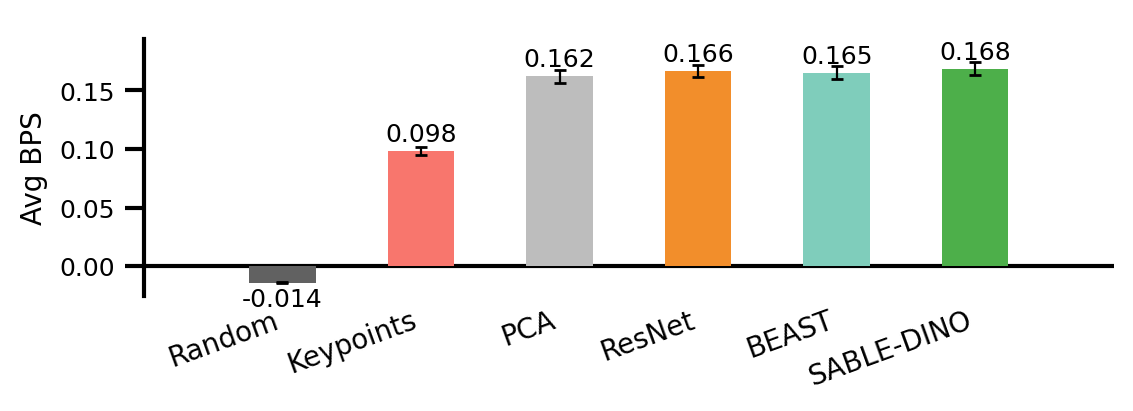

In [ ]:
results_dir = Path("/projects/bfsr/xdai3/project3d/iclr_plotting/SABLE_zero_shot_encoding")

plot_encoders = "cnn"
eids = [
    "4b00df29-3769-43be-bb40-128b1cba6d35",
    "72cb5550-43b4-4ef0-add5-e4adfdfb5e02",
    "781b35fd-e1f0-4d14-b2bb-95b7263082bb"
]
bps_source = "per-neuron"
methods = ["random_baseline", "keypoints", "pca", "resnet", "beast", "sable_dino"]
method_labels = ["Random", "Keypoints", "PCA", "ResNet", "BEAST", "SABLE-DINO"]
rrr_label = None
tcn_label = None
y_label = None

# same base hues as the decoding plots' BAR_COLOR_PAIRS (Keypoints/BEAST/SABLE/PCA/ResNet),
# extended with a color for random_baseline in the same style. When plotting both RRR and CNN
# bars, CNN is lightened to distinguish it from RRR; when only one is plotted (the default),
# it uses the base color directly, matching decoding's un-lightened single-bar style.
ENCODING_BASE_COLORS = {
    "random_baseline": "#616161",
    "keypoints": "#F8766D",
    "pca": "#7FCDBB",
    "resnet": "#4DAF4A",
    "beast": "#BDBDBD",
    "sable_dino": "#F28E2B",
}


def _lightened_hex(hex_color: str) -> str:
    return mcolors.to_hex(tuple(min(1.0, 0.52 + 0.48 * c) for c in mcolors.to_rgb(hex_color)))


BAR_COLOR_PAIRS = [
    (
        ENCODING_BASE_COLORS[method],
        _lightened_hex(ENCODING_BASE_COLORS[method]) if plot_encoders == "both" else ENCODING_BASE_COLORS[method],
    )
    for method in methods
]

if plot_encoders not in {"cnn", "rrr", "both"}:
    raise ValueError(f"Unknown plot_encoders: {plot_encoders!r}")

results_dir = results_dir.expanduser().resolve()
allowed = _allowed_eid_set(eids if eids is not None else EID_SET)
n = len(methods)
means_rrr = np.full(n, np.nan)
means_cnn = np.full(n, np.nan)
se_rrr = np.full(n, np.nan)
se_cnn = np.full(n, np.nan)

for i, method in enumerate(methods):
    sub = results_dir / method
    if bps_source == "stored":
        agg = aggregate_bps_for_method(sub, allowed)
    elif bps_source == "per-neuron":
        agg = aggregate_bps_vectors_for_method(sub, allowed)
    else:
        raise ValueError(f"Unknown bps_source: {bps_source!r}")
    if agg is None:
        continue
    rrr, cnn = agg
    if bps_source == "stored":
        means_rrr[i] = float(np.mean(rrr))
        means_cnn[i] = float(np.mean(cnn))
        se_rrr[i] = float(np.std(rrr, ddof=1) / np.sqrt(rrr.size)) if rrr.size > 1 else 0.0
        se_cnn[i] = float(np.std(cnn, ddof=1) / np.sqrt(cnn.size)) if cnn.size > 1 else 0.0
    else:
        means_rrr[i], se_rrr[i] = _mean_and_standard_error(rrr)
        means_cnn[i], se_cnn[i] = _mean_and_standard_error(cnn)

width = 0.36 if plot_encoders == "both" else 0.5
# bar centers spaced by less than 1.0 pulls groups closer on the x axis (vs np.arange alone).
bar_center_spacing = 1.04166666667
x = np.arange(n, dtype=np.float64) * bar_center_spacing
fig, ax = plt.subplots(figsize=(0.93 * n, 2.0), dpi=200)

relevant_means = np.concatenate([
    means_rrr[np.isfinite(means_rrr)] if plot_encoders in {"rrr", "both"} else np.array([]),
    means_cnn[np.isfinite(means_cnn)] if plot_encoders in {"cnn", "both"} else np.array([]),
])
y_max = float(relevant_means.max()) if relevant_means.size else 1.0
y_min_data = float(relevant_means.min()) if relevant_means.size else 0.0
y_lim = y_max * 1.15
# leave headroom below zero (plus room for a below-bar label) whenever a bar dips negative,
# so a near-zero value's bar and text label don't collide with the zero line.
label_offset = y_lim * 0.02
y_min = min(0.0, y_min_data - 3 * label_offset)


def _label_position(value: float) -> tuple[float, str]:
    """Label sits above positive bars and below negative/near-zero bars."""
    if value >= 0:
        return value + label_offset, "bottom"
    return value - label_offset, "top"


first_rrr_legend = True
first_cnn_legend = True
for i, _ in enumerate(methods):
    c_rrr, c_cnn = bar_color_pair(i)
    if plot_encoders in {"rrr", "both"} and np.isfinite(means_rrr[i]):
        xpos = x[i] - width / 2 if plot_encoders == "both" else x[i]
        ax.bar(
            xpos,
            means_rrr[i],
            width,
            yerr=se_rrr[i],
            color=c_rrr,
            edgecolor="none",
            linewidth=2,
            capsize=2,
            error_kw={"elinewidth": 0.8},
            label=rrr_label if first_rrr_legend else None,
        )
        first_rrr_legend = False
        y_text, va_text = _label_position(means_rrr[i])
        ax.text(
            xpos,
            y_text,
            f"{means_rrr[i]:.3f}",
            ha="center",
            va=va_text,
            fontsize=9,
        )
    if plot_encoders in {"cnn", "both"} and np.isfinite(means_cnn[i]):
        xpos = x[i] + width / 2 if plot_encoders == "both" else x[i]
        ax.bar(
            xpos,
            means_cnn[i],
            width,
            yerr=se_cnn[i],
            color=c_cnn,
            edgecolor="none",
            linewidth=2,
            capsize=2,
            error_kw={"elinewidth": 0.8},
            label=tcn_label if first_cnn_legend else None,
        )
        first_cnn_legend = False
        y_text, va_text = _label_position(means_cnn[i])
        ax.text(
            xpos,
            y_text,
            f"{means_cnn[i]:.3f}",
            ha="center",
            va=va_text,
            fontsize=9,
        )

fontweight = "medium"
ax.set_xticks(x)
ax.set_xticklabels(method_labels, rotation=20, ha="right", fontsize=10, fontweight=fontweight)
ax.set_ylabel(y_label or "Avg BPS", fontsize=10, fontweight=fontweight)
ax.tick_params(axis="y", labelsize=9, width=1.5, length=7, direction="out")
ax.tick_params(axis="x", length=0, width=2.25)
plt.setp(ax.get_yticklabels(), fontweight=fontweight)
plt.setp(ax.get_xticklabels(), fontweight=fontweight)

ax.set_ylim(y_min, y_lim)
ax.grid(False)

for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
# zero-reference line in place of the bottom spine, since the axes now extend below zero
# to make room for negative bars (e.g. random_baseline).
ax.axhline(0, color="black", linewidth=1.5, zorder=0.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.12),
    frameon=False,
    ncol=2,
    fontsize=8,
    handlelength=1.2,
    columnspacing=1.2,
)

ax.set_xlim(x.min() - bar_center_spacing, x.max() + bar_center_spacing)
fig.tight_layout(pad=0.4)
fig.savefig(
    "/u/xdai3/project3d/SABLE_repo_3/beast/scripts/neural_analysis/plots/encoding_barplot.png",
    dpi=400,              # try 300 for print; 600 if you need extra sharpness
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
)
plt.show()

## Decoding metrics

In [ ]:
# from analyses.neural_analysis.plot_helpers import iter_eid_metrics_npys
def iter_eid_metrics_npys(
    method_dir: Path,
    allowed_eids: frozenset[str] | None):
    """Yield ``psnr_ssim_metrics.npz`` paths for matching EID folders.

    If ``allowed_eids`` is set, only directories whose **name** is in that set (compared
    via :func:`normalize_eid`) are searched. Exactly one ``psnr_ssim_metrics.npz`` file
    is expected under each matching EID directory. If ``allowed_eids`` is ``None``,
    every matching file under ``method_dir`` is included.

    """
    if not method_dir.is_dir():
        return
    if allowed_eids is None:
        yield from method_dir.rglob("psnr_ssim_metrics.npz")
        return

    seen: set[Path] = set()
    for d in method_dir.rglob("*"):
        if not d.is_dir() or normalize_eid(d.name) not in allowed_eids:
            continue
        matches = sorted(met for met in d.rglob("psnr_ssim_metrics.npz") if met.is_file())
        if len(matches) > 1:
            raise ValueError(
                f"Expected one psnr_ssim_metrics.npz under EID directory {d}, "
                f"found {len(matches)}: {[str(p) for p in matches]}"
            )
        if matches and matches[0] not in seen:
            seen.add(matches[0])
            yield matches[0]

In [ ]:

results_dir=Path("/projects/bfsr/xdai3/project3d/iclr_plotting/SABLE_zero_shot_decoding")
def aggregate_metrics_vectors_for_method(
    method_dir: Path,
    allowed_eids: frozenset[str] | None,
) -> tuple[np.ndarray, np.ndarray] | None:
    """Collect per-frame PSNR and SSIM vectors across all matching EIDs."""
    psnr_vectors: list[np.ndarray] = []
    ssim_vectors: list[np.ndarray] = []

    print(iter_eid_metrics_npys(method_dir, allowed_eids))
    for npy in sorted(iter_eid_metrics_npys(method_dir, allowed_eids), key=lambda p: p.parent.name):
        metrics = np.load(npy)
        psnr_vectors.append(_finite_1d(metrics["psnr"]))
        ssim_vectors.append(_finite_1d(metrics["ssim"]))
    if not psnr_vectors:
        return None
    return np.concatenate(psnr_vectors), np.concatenate(ssim_vectors)



In [ ]:
methods = ["resnet", "beast", "sable"]
method_labels = ["ResNet AE", "BEAST", "SABLE"]
n = len(method_labels)
means_psnr = np.full(n, np.nan)
means_ssim = np.full(n, np.nan)
se_psnr = np.full(n, np.nan)
se_ssim = np.full(n, np.nan)

i = 0
for j, method in enumerate(methods):
    sub = results_dir / method
    agg = aggregate_metrics_vectors_for_method(sub, allowed)
    if agg is not None:
        psnr, ssim = agg
        means_psnr[i], se_psnr[i] = _mean_and_standard_error(psnr)
        means_ssim[i], se_ssim[i] = _mean_and_standard_error(ssim)
        i +=1

<generator object iter_eid_metrics_npys at 0x7f856916f7d0>
<generator object iter_eid_metrics_npys at 0x7f856916f7d0>
<generator object iter_eid_metrics_npys at 0x7f856916f7d0>


In [ ]:
print(means_psnr,means_ssim)
print(se_psnr,se_ssim)

[16.67891439 17.16074938 20.11377503] [0.73717592 0.74143205 0.88130302]
[0.01143628 0.0123069  0.01354182] [0.00014754 0.00015713 0.00021503]


### SSIM

/tmp/ipykernel_3186162/4082140305.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


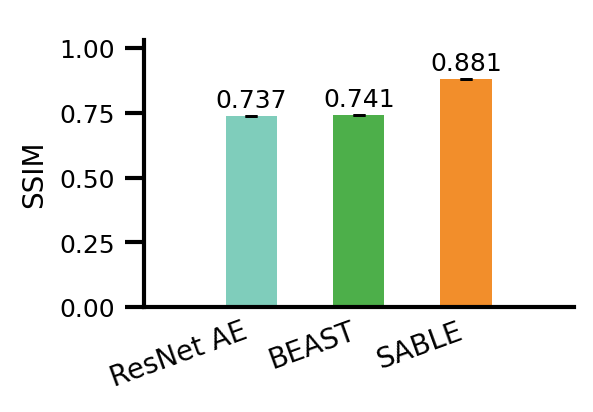

In [ ]:
# similar pastel pairs to your example
BAR_COLOR_PAIRS = [
    # ("#F8766D", "#F8766D"),  # Keypoints
    ("#7FCDBB", "#7FCDBB"),  # BEAST
    ("#4DAF4A", "#4DAF4A"),  # SABLE
    # ("#BDBDBD", "#BDBDBD"),  # PCA
    ("#F28E2B", "#F28E2B"),  # ResNet
]

plot_encoders = "ssim"
y_label = plot_encoders


n = len(method_labels)

fig, ax = plt.subplots(figsize=(2.8, 2.), dpi=200)

width = 0.5
# Bar centers spaced by less than 1.0 pulls groups closer on the x axis (vs np.arange alone).
bar_center_spacing = 1.04166666667
x = np.arange(n, dtype=float) * bar_center_spacing

for i, _ in enumerate(methods):
    c_rrr, c_cnn = BAR_COLOR_PAIRS[i % len(BAR_COLOR_PAIRS)]

    if plot_encoders in {"ssim", "both"} and np.isfinite(means_ssim[i]):
        y_label = "SSIM"
        y_lim = max(means_ssim) + 0.15
        xpos = x[i] + width / 2 if plot_encoders == "both" else x[i]
        ax.bar(
            xpos, means_ssim[i], width,
            yerr=se_ssim[i],
            color=c_cnn,
            edgecolor="none",   # <-- remove edge
            linewidth=2,
            capsize=2,
            error_kw={"elinewidth": 0.8},
        )
        ax.text(
            xpos, means_ssim[i] + 0.015,
            f"{means_ssim[i]:.3f}",
            ha="center", va="bottom",
            fontsize=9,
        )

fontweight="medium"
ax.set_xticks(x)
ax.set_xticklabels(method_labels, rotation=20, ha="right", fontsize=10, fontweight=fontweight)
ax.set_xlim(x.min() - bar_center_spacing / 2, x.max() + bar_center_spacing / 2)
ax.set_ylabel(y_label or "Avg BPS", fontsize=10, fontweight=fontweight)
ax.tick_params(axis="y", labelsize=9, width=1.5, length=7, direction="out")
ax.tick_params(axis="x", length=0, width=2.25)
plt.setp(ax.get_yticklabels(), fontweight=fontweight)
plt.setp(ax.get_xticklabels(), fontweight=fontweight)

# match attached figure style
ax.set_ylim(0.0, y_lim)
ax.grid(False)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

for side in ["left", "bottom"]:
    ax.spines[side].set_linewidth(1.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.12),
    frameon=False,
    ncol=2,
    fontsize=8,
    handlelength=1.2,
    columnspacing=1.2,
)

ax.set_xlim(x.min() - bar_center_spacing, x.max() + bar_center_spacing)
fig.tight_layout(pad=0.4)
# fig.savefig(
#     "/u/yzhang39/E-RayZer-private/notebooks/barplot.png",
#     dpi=400,              # try 300 for print; 600 if you need extra sharpness
#     bbox_inches="tight",
#     pad_inches=0.05,
#     facecolor="white",
# )
plt.show()

### PSNR

/tmp/ipykernel_2698326/3198777675.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


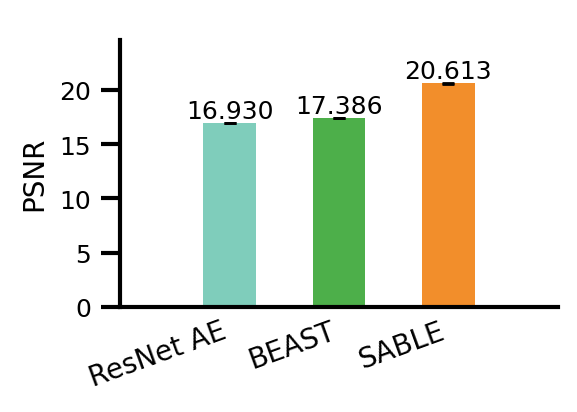

In [ ]:
# similar pastel pairs to your example
BAR_COLOR_PAIRS = [
    # ("#F8766D", "#F8766D"),  # Keypoints
    ("#7FCDBB", "#7FCDBB"),  # BEAST
    ("#4DAF4A", "#4DAF4A"),  # SABLE
    # ("#BDBDBD", "#BDBDBD"),  # PCA
    ("#F28E2B", "#F28E2B"),  # ResNet
]

plot_encoders = "psnr"
y_label = plot_encoders


n = len(method_labels)

fig, ax = plt.subplots(figsize=(2.8, 2.), dpi=200)

width = 0.5
# Bar centers spaced by less than 1.0 pulls groups closer on the x axis (vs np.arange alone).
bar_center_spacing = 1.04166666667
x = np.arange(n, dtype=float) * bar_center_spacing

for i, _ in enumerate(methods):
    c_rrr, c_cnn = BAR_COLOR_PAIRS[i % len(BAR_COLOR_PAIRS)]

    if plot_encoders in {"psnr", "both"} and np.isfinite(means_psnr[i]):
        y_label = "PSNR"
        y_lim = max(means_psnr) + 4
        xpos = x[i] + width / 2 if plot_encoders == "both" else x[i]
        ax.bar(
            xpos, means_psnr[i], width,
            yerr=se_psnr[i],
            color=c_cnn,
            edgecolor="none",   # <-- remove edge
            linewidth=2,
            capsize=2,
            error_kw={"elinewidth": 0.8},
        )
        ax.text(
            xpos, means_psnr[i] + 0.015,
            f"{means_psnr[i]:.3f}",
            ha="center", va="bottom",
            fontsize=9,
        )

fontweight="medium"
ax.set_xticks(x)
ax.set_xticklabels(method_labels, rotation=20, ha="right", fontsize=10, fontweight=fontweight)
ax.set_xlim(x.min() - bar_center_spacing / 2, x.max() + bar_center_spacing / 2)
ax.set_ylabel(y_label or "Avg BPS", fontsize=10, fontweight=fontweight)
ax.tick_params(axis="y", labelsize=9, width=1.5, length=7, direction="out")
ax.tick_params(axis="x", length=0, width=2.25)
plt.setp(ax.get_yticklabels(), fontweight=fontweight)
plt.setp(ax.get_xticklabels(), fontweight=fontweight)

# match attached figure style
ax.set_ylim(0.0, y_lim)
ax.grid(False)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

for side in ["left", "bottom"]:
    ax.spines[side].set_linewidth(1.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.12),
    frameon=False,
    ncol=2,
    fontsize=8,
    handlelength=1.2,
    columnspacing=1.2,
)

ax.set_xlim(x.min() - bar_center_spacing, x.max() + bar_center_spacing)
fig.tight_layout(pad=0.4)
# fig.savefig(
#     "/u/yzhang39/E-RayZer-private/notebooks/barplot.png",
#     dpi=400,              # try 300 for print; 600 if you need extra sharpness
#     bbox_inches="tight",
#     pad_inches=0.05,
#     facecolor="white",
# )
plt.show()